In [76]:
import numpy as np
import matplotlib.pyplot as plt
# Removed: import seaborn as sns 
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, \
                            precision_score, recall_score, f1_score, \
                            classification_report
import tensorflow as tf
import os # Needed for saving plots in callback

# Assume your val_dataset is already defined and batched
# Example: val_dataset = tf.keras.preprocessing.image_dataset_from_directory(...)

# ---------------------------------------------------------------------------
# 1. Standalone Function for Post-Training Analysis (Matplotlib)
# ---------------------------------------------------------------------------

def analyze_model_outputs(model: tf.keras.Model, 
                          val_dataset: tf.data.Dataset, 
                          dataset_name: str = "Validation",
                          METRIC_THRESHOLD: float = 0.5):
    """
    Analyzes model predictions on a given dataset using Matplotlib for histograms.

    Args:
        model: The trained Keras model.
        val_dataset: The tf.data.Dataset to evaluate on.
        dataset_name: Name for plot titles (e.g., "Validation", "Test").
    """
    print(f"\n--- Analyzing Model Outputs on {dataset_name} Set ---")

    # --- Get Predictions and True Labels ---
    print("Gathering predictions and true labels...")
    try:
        predictions_raw = model.predict(val_dataset)
        true_labels = []
        for _, y_batch in val_dataset:
            true_labels.append(y_batch.numpy())
        true_labels = np.concatenate(true_labels, axis=0).flatten()
        predictions_proba = predictions_raw.flatten()

        if len(predictions_proba) != len(true_labels):
             print(f"Warning: Number of predictions ({len(predictions_proba)}) "
                   f"does not match number of labels ({len(true_labels)}). "
                   f"Check dataset configuration.")
             # Attempt to reconcile if predictions has an extra dim (unlikely here)
             if predictions_proba.shape[0] != true_labels.shape[0] and len(predictions_proba.shape) > 1:
                 print("Attempting to flatten predictions further.")
                 predictions_proba = predictions_proba.reshape(-1) # Or adjust based on actual shape
                 if len(predictions_proba) != len(true_labels):
                     raise ValueError("Cannot reconcile prediction and label shapes.")

    except Exception as e:
        print(f"Error during prediction or label extraction: {e}")
        print("Check dataset structure and model output shape.")
        return

    print(f"Successfully gathered {len(true_labels)} labels and predictions.")

    # --- Plot Histogram of Predicted Probabilities (Matplotlib) ---
    print("Plotting histogram of predicted probabilities...")
    plt.figure(figsize=(10, 6))
    # Use plt.hist instead of sns.histplot
    # density=True normalizes the histogram (area sums to 1)
    # alpha adds transparency
    plt.hist(predictions_proba, bins=50, density=True, alpha=0.75, color='blue', edgecolor='black') 
    plt.title(f'Histogram of Predicted Probabilities ({dataset_name} Set)')
    plt.xlabel('Predicted Probability (Class 1)')
    plt.ylabel('Density') # Changed label to Density since density=True
    plt.grid(True, axis='y', linestyle='--')
    plt.show()

    # --- Calculate AUC ---
    try:
        auc_score = roc_auc_score(true_labels, predictions_proba)
        print(f"\nArea Under ROC Curve (AUC): {auc_score:.4f}")
    except ValueError as e:
        print(f"\nCould not calculate AUC: {e}. This might happen if only one class is present in true labels.")
        auc_score = None

    # --- Find Best Threshold based on F1 Score ---
    print("\nCalculating metrics across different thresholds...")
    precision_pts, recall_pts, thresholds = precision_recall_curve(true_labels, predictions_proba)
    thresholds = thresholds[:len(precision_pts)-1] 
    f1_scores = []
    for p, r in zip(precision_pts[:-1], recall_pts[:-1]):
         if (p + r) > 0: f1 = 2 * (p * r) / (p + r)
         else: f1 = 0.0
         f1_scores.append(f1)

    if not f1_scores:
         print("Could not calculate F1 scores across thresholds.")
         best_threshold = 0.5
         best_f1 = 0.0
    else:
         best_f1_idx = np.argmax(f1_scores)
         best_threshold = thresholds[best_f1_idx]
         best_f1 = f1_scores[best_f1_idx]
         print(f"Best Threshold (Maximizing F1): {best_threshold:.4f}")
         print(f"Best F1 Score at this threshold: {best_f1:.4f}")

         # Optional: Plot Precision-Recall Curve (already using Matplotlib)
         plt.figure(figsize=(10, 6))
         pr_auc = auc(recall_pts, precision_pts)
         plt.plot(recall_pts, precision_pts, label=f'PR curve (area = {pr_auc:.2f})')
         plt.scatter(recall_pts[best_f1_idx], precision_pts[best_f1_idx], marker='o', color='red', label=f'Best F1 Threshold ({best_threshold:.2f})')
         plt.xlabel('Recall')
         plt.ylabel('Precision')
         plt.title(f'Precision-Recall Curve ({dataset_name} Set)')
         plt.legend()
         plt.grid(True)
         plt.show()

    # --- Calculate Metrics at the Chosen Threshold ---
    print(f"\nMetrics using threshold = {best_threshold:.4f}:")
    final_predictions = (predictions_proba >= best_threshold).astype(int)
    try:
        print(classification_report(true_labels, final_predictions))
    except ValueError as e:
        print(f"Could not generate classification report: {e}")

    # --- Calculate Metrics at the config Threshold ---
    print(f"\nMetrics using threshold = {METRIC_THRESHOLD:.4f}:")
    final_predictions = (predictions_proba >= METRIC_THRESHOLD).astype(int)
    try:
        print(classification_report(true_labels, final_predictions))
    except ValueError as e:
        print(f"Could not generate classification report: {e}")

    print("--- Analysis Complete ---")
    # --- Calculate Area Under Precision-Recall Curve (PR AUC) ---
    try:
        pr_auc_score = auc(recall_pts, precision_pts)
        print(f"Area Under Precision-Recall Curve (PR AUC): {pr_auc_score:.4f}")
    except Exception as e:
        print(f"Could not calculate PR AUC: {e}")

# ---------------------------------------------------------------------------
# 2. Custom Callback for Analysis During Training (Matplotlib)
# ---------------------------------------------------------------------------

class OutputAnalysisCallback(tf.keras.callbacks.Callback):
    """
    Callback to analyze model outputs (histogram, metrics) during training 
    using Matplotlib for histograms.
    """
    def __init__(self, validation_data, log_dir, run_freq=5, dataset_name="Validation"):
        """
        Args:
            validation_data (tf.data.Dataset): The validation dataset.
            log_dir (str): Directory to save plots.
            run_freq (int): How often (in epochs) to run the analysis.
            dataset_name (str): Name for plot titles.
        """
        super().__init__()
        self.validation_data = validation_data
        self.log_dir = log_dir
        self.run_freq = run_freq
        self.dataset_name = dataset_name
        
        print("Callback: Extracting true labels from validation data...")
        try:
            true_labels_list = []
            for _, y_batch in self.validation_data: 
                true_labels_list.append(y_batch.numpy())
            self.true_labels = np.concatenate(true_labels_list, axis=0).flatten()
            print(f"Callback: Successfully extracted {len(self.true_labels)} labels.")
        except Exception as e:
            print(f"Callback Error: Failed to extract true labels - {e}. Analysis might fail.")
            self.true_labels = None
            
        os.makedirs(self.log_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.run_freq == 0 and self.true_labels is not None:
            print(f"\n--- Running Output Analysis Callback: Epoch {epoch + 1} ---")
            
            # --- Get Predictions ---
            predictions_raw = self.model.predict(self.validation_data)
            predictions_proba = predictions_raw.flatten()

            if len(predictions_proba) != len(self.true_labels):
                print(f"Callback Warning: Epoch {epoch+1} - Predictions ({len(predictions_proba)}) "
                      f"mismatched with labels ({len(self.true_labels)}). Skipping analysis.")
                return

            # --- Plot Histogram (Matplotlib) ---
            plt.figure(figsize=(10, 6))
            # Use plt.hist instead of sns.histplot
            plt.hist(predictions_proba, bins=50, density=True, alpha=0.75, color='blue', edgecolor='black')
            plt.title(f'Histogram of Predicted Probabilities (Epoch {epoch + 1} - {self.dataset_name})')
            plt.xlabel('Predicted Probability (Class 1)')
            plt.ylabel('Density') # Changed label
            plt.grid(True, axis='y', linestyle='--')
            plot_path = os.path.join(self.log_dir, f'predictions_hist_epoch_{epoch + 1}.png')
            try:
                plt.savefig(plot_path)
                print(f"Saved prediction histogram to {plot_path}")
            except Exception as e:
                print(f"Error saving histogram: {e}")
            plt.close() # Close plot to avoid displaying it now

            # --- Calculate AUC ---
            try:
                 auc_score = roc_auc_score(self.true_labels, predictions_proba)
                 print(f"Epoch {epoch + 1} - AUC: {auc_score:.4f}")
            except ValueError as e:
                 print(f"Epoch {epoch + 1} - Could not calculate AUC: {e}")

            # --- Find Best Threshold & F1 ---
            precision_pts, recall_pts, thresholds = precision_recall_curve(self.true_labels, predictions_proba)
            thresholds = thresholds[:len(precision_pts)-1]
            f1_scores = []
            for p, r in zip(precision_pts[:-1], recall_pts[:-1]):
                 f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0.0
                 f1_scores.append(f1)

            if f1_scores:
                 best_f1_idx = np.argmax(f1_scores)
                 best_threshold = thresholds[best_f1_idx]
                 best_f1 = f1_scores[best_f1_idx]
                 print(f"Epoch {epoch + 1} - Best F1 Threshold: {best_threshold:.4f} (F1: {best_f1:.4f})")
            else:
                 print(f"Epoch {epoch + 1} - Could not calculate F1 scores across thresholds.")

            print(f"--- Callback Analysis Complete: Epoch {epoch + 1} ---\n")

# ---------------------------------------------------------------------------
# How to Use (No changes needed here from previous version)
# ---------------------------------------------------------------------------
# (Use the standalone function or integrate the callback into train_transfer_model 
# exactly as described in the previous response)
# ...

In [2]:
import json
import numpy as np
import os
import sys
import time
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)
import src.data_pipeline as dp
from src.config import Config
from src.model import create_model
from src.train import compile_model

In [78]:
my_config = Config()
# my_config.MODEL_ARCHITECTURE = 'resnet50'
my_config.SHUFFLE_DATASET = False
params = {"MASK_VALUE": 20, "AUGMENT_DATA": True, "NORMALIZE_IMAGES": True, "MASK_BG": True, "HEAD_DENSE_UNITS": 512, "MODEL_ARCHITECTURE": 'resnet50', 'FINE_TUNE_FROM_LAYER': 165, 'HEAD_ARCHITECTURE': "deep_combo", "TAP_INTO_BASE_MODEL": False, "NUM_FINE_TUNE_EPOCHS": 30}
#{"MASK_VALUE": 128, "AUGMENT_DATA": True, "NORMALIZE_IMAGES": True,  "MASK_BG": True, "HEAD_DENSE_UNITS": 64, "MODEL_ARCHITECTURE": 'vgg16', 'FINE_TUNE_FROM_LAYER': 15, 'HEAD_ARCHITECTURE': "shallow"}
for key, value in params.items():
    setattr(my_config, key, value)        
# my_config.INITIAL_LR = 0.01
raw_json_path = "C:/Users/anedaeij23/Project/tooth_classification_project/data/raw/complete_toothwise_annotations.json"
intrim_dir = "/home/arash/tooth_classification_project/data/processed"
img_dir = "C:/Users/anedaeij23/Project/tooth_classification_project/data/raw"

dataset_name = 'test'

In [4]:
my_config.SHUFFLE_DATASET

False

In [79]:
ds_json_path = os.path.join(intrim_dir, f"Pla_filtered_{dataset_name}.json")
val_records = dp.parse_dataset_json(ds_json_path, my_config, is_train_ds=False)
val_records_updated, _   = dp.preprocess_and_save_images(val_records, my_config, dataset_name)
val_ds   = dp.build_tf_dataset_from_preprocessed(val_records_updated, my_config)

Processed folder '/home/arash/tooth_classification_project/data/processed/Pla_20_42_1_1_1_0.25_0.015' and records file exist. Loading records...


In [49]:
def print_dataset_stats(dataset, name="Dataset"):
    total = 0
    class_counts = {0: 0, 1: 0}
    for x, y in dataset:
        total += len(y)
        for label in y.numpy():
            class_counts[int(label)] += 1
    print(f"{name} statistics:")
    print(f"Total samples: {total}")
    print(f"Class distribution: {class_counts}")

# Add before training
print_dataset_stats(val_ds, dataset_name)

2025-05-15 20:01:14.177669: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_1/branch_executed/_77


test statistics:
Total samples: 1002
Class distribution: {0: 866, 1: 136}


###############Base model frozen
base model is supposed to be at model.layers[2]. Found layer name is : resnet50. is it correct?!
####### Set layers 165 and higher in base model 'resnet50', and the head to trainable

Analyzing model state AFTER INITIAL training:

--- Analyzing Model Outputs on test Set ---
Gathering predictions and true labels...


2025-05-15 21:07:47.589651: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_tfg_inlined_cond_0_1/branch_executed/_77
2025-05-15 21:07:47.706332: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_tfg_inlined_cond_0_1/branch_executed/_77


32/32 [==============================] - 4s 96ms/step


2025-05-15 21:07:51.555319: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_tfg_inlined_cond_0_1/branch_executed/_77


Successfully gathered 1002 labels and predictions.
Plotting histogram of predicted probabilities...


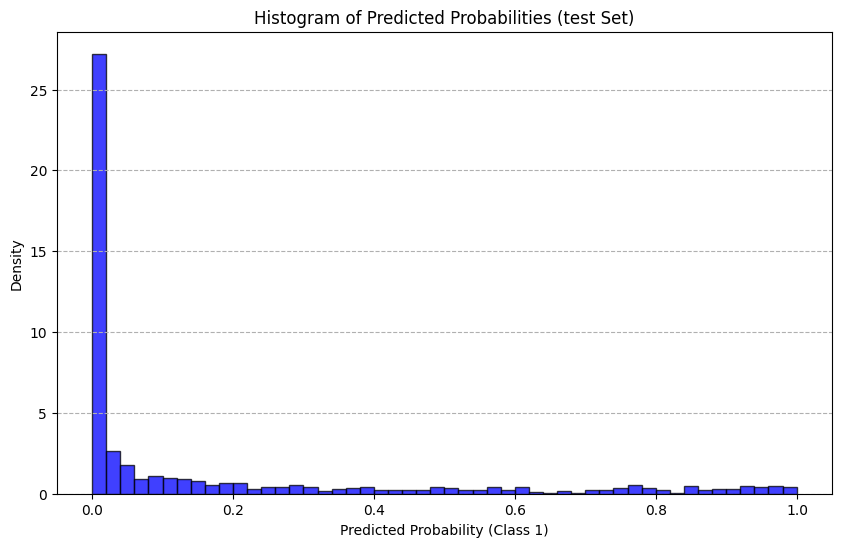


Area Under ROC Curve (AUC): 0.7817

Calculating metrics across different thresholds...
Best Threshold (Maximizing F1): 0.5766
Best F1 Score at this threshold: 0.4788


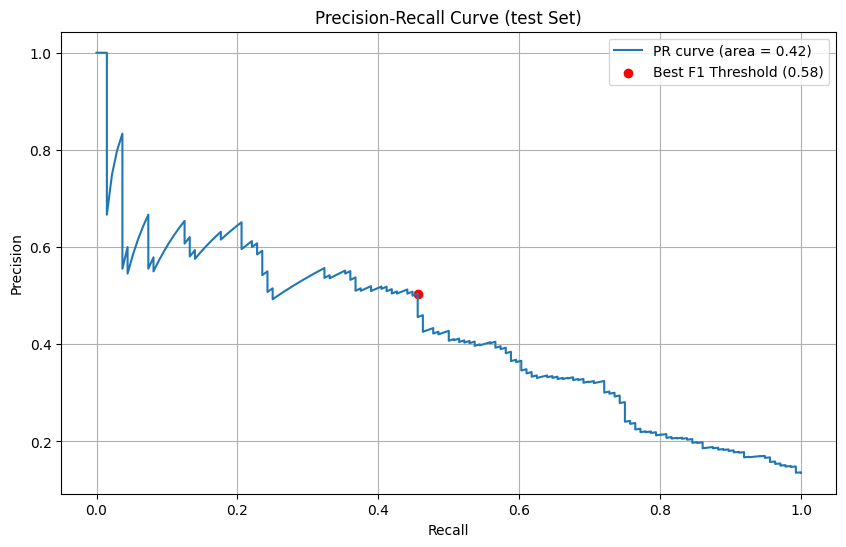


Metrics using threshold = 0.5766:
              precision    recall  f1-score   support

         0.0       0.92      0.93      0.92       866
         1.0       0.50      0.46      0.48       136

    accuracy                           0.87      1002
   macro avg       0.71      0.69      0.70      1002
weighted avg       0.86      0.87      0.86      1002


Metrics using threshold = 0.5800:
              precision    recall  f1-score   support

         0.0       0.91      0.93      0.92       866
         1.0       0.50      0.45      0.47       136

    accuracy                           0.87      1002
   macro avg       0.71      0.69      0.70      1002
weighted avg       0.86      0.87      0.86      1002

--- Analysis Complete ---
Area Under Precision-Recall Curve (PR AUC): 0.4221


In [80]:
# ---------------------------------------------------------------------------
# How to Use
# ---------------------------------------------------------------------------

# --- Using the Standalone Function ---
# Assume 'mymodel' is your trained model after calling train_transfer_model
# or loaded from saved weights.
# Assume 'val_dataset' is your validation tf.data.Dataset

# analyze_model_outputs(mymodel, val_dataset, dataset_name="Validation")
from src.utils import set_trainable_layers_new
# If you saved weights after initial training and want to analyze that state:
initial_weights_path = os.path.join("/home/arash/tooth_classification_project/logs/tensorboard", "resnet50/20250515-143232/best_pr_auc_weights-epoch_0020_prauc_0.49.h5") # Get the correct path
# initial_weights_path = os.path.join("/home/arash/tooth_classification_project/logs/tensorboard", "best_pr_auc_weights-epoch_0014_prauc_0.46.h5")
# model_arch = 'ConvNeXtTiny' # Or whichever architecture was used
# input_s = (224, 224, 3) # Use your actual input shape
tf.keras.backend.clear_session()
model_for_initial_analysis = create_model(my_config, 'transfer', trainable_base = False) # Build with same structure
# model_for_initial_analysis.trainable = False # Set to False if you want to analyze without fine-tuning
model_for_initial_analysis = set_trainable_layers_new(model_for_initial_analysis, my_config.FINE_TUNE_FROM_LAYER)

model_for_initial_analysis.load_weights(initial_weights_path, by_name=False)

# Set model to inference mode before loading weights
model_for_initial_analysis.trainable = False
for layer in model_for_initial_analysis.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model_for_initial_analysis = compile_model(model_for_initial_analysis, my_config, my_config.INITIAL_LR)
print("\nAnalyzing model state AFTER INITIAL training:")
analyze_model_outputs(model_for_initial_analysis, val_ds, dataset_name=f"{dataset_name}", METRIC_THRESHOLD=0.58)

2025-05-15 21:12:49.908896: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_tfg_inlined_cond_0_1/branch_executed/_77
2025-05-15 21:12:50.262709: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_tfg_inlined_cond_0_1/branch_executed/_77
2025-05-15 21:12:50.371110: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_tfg_inlined_cond_0_1/branch_executed/_77


32/32 [==============================] - 3s 99ms/step


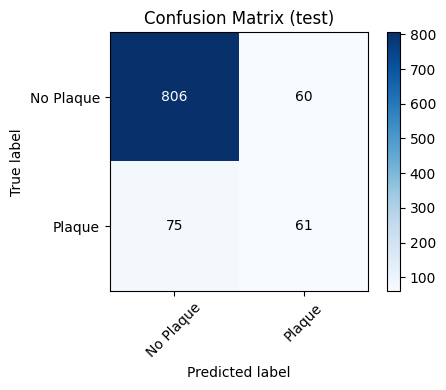

In [81]:
import numpy as np
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

def plot_confusion_matrix(model, dataset, threshold=0.5, dataset_name="Validation"):
    """
    Plots the confusion matrix for binary classification results.

    Args:
        model: Trained Keras model.
        dataset: tf.data.Dataset with (images, labels).
        threshold: Probability threshold for positive class.
        dataset_name: Name for plot title.
    """
    # Get predictions and true labels
    y_true = []
    for _, y_batch in dataset:
        y_true.append(y_batch.numpy())
    y_true = np.concatenate(y_true, axis=0).flatten()

    y_pred_proba = model.predict(dataset).flatten()
    y_pred = (y_pred_proba >= threshold).astype(int)

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    classes = ["No Plaque", "Plaque"]

    # Plot
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Print numbers inside the squares
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

# Example usage:
plot_confusion_matrix(model_for_initial_analysis, val_ds, threshold=0.58, dataset_name=dataset_name)

In [43]:
model_for_initial_analysis.summary()

Model: "resnet50_model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 preprocessing_layer (Lambd  (None, 256, 256, 3)          0         ['input_2[0][0]']             
 a)                                                                                               
                                                                                                  
 resnet50 (Functional)       (None, 8, 8, 2048)           2358771   ['preprocessing_layer[0][0]'] 
                                                          2                                       
                                                                                     

In [34]:
def compare_weight_files(working_weights_path: str, problematic_weights_path: str):
    """
    Compare two .h5 weight files to identify structural differences.
    
    Args:
        working_weights_path: Path to the weights file that loads successfully
        problematic_weights_path: Path to the weights file that has issues
    """
    print("=== Weight Files Comparison Analysis ===\n")
    
    try:
        import h5py
        
        # Open both files
        with h5py.File(working_weights_path, 'r') as working_f, \
             h5py.File(problematic_weights_path, 'r') as problem_f:
             
            def compare_group_contents(group1, group2, path=""):
                """Recursively compare contents of two h5py groups"""
                differences = []
                
                # Get all items in both groups
                items1 = set(group1.keys())
                items2 = set(group2.keys())
                
                # Find items unique to each group
                only_in_1 = items1 - items2
                only_in_2 = items2 - items1
                common_items = items1 & items2
                
                # Report unique items
                if only_in_1:
                    differences.append(f"Only in working file at {path}: {sorted(only_in_1)}")
                if only_in_2:
                    differences.append(f"Only in problem file at {path}: {sorted(only_in_2)}")
                
                # Compare common items
                for name in common_items:
                    item1 = group1[name]
                    item2 = group2[name]
                    
                    # If both are groups, recurse
                    if isinstance(item1, h5py.Group) and isinstance(item2, h5py.Group):
                        nested_diffs = compare_group_contents(item1, item2, f"{path}/{name}")
                        differences.extend(nested_diffs)
                    
                    # If both are datasets, compare shapes and data
                    elif isinstance(item1, h5py.Dataset) and isinstance(item2, h5py.Dataset):
                        if item1.shape != item2.shape:
                            differences.append(
                                f"Shape mismatch at {path}/{name}:\n"
                                f"  Working: {item1.shape}\n"
                                f"  Problem: {item2.shape}"
                            )
                        # Optionally compare actual values
                        elif not np.allclose(item1[()], item2[()], rtol=1e-5, atol=1e-8):
                            differences.append(
                                f"Value mismatch at {path}/{name} "
                                f"(shapes match but values differ)"
                            )
                    
                    # If types don't match
                    else:
                        differences.append(
                            f"Type mismatch at {path}/{name}:\n"
                            f"  Working: {type(item1)}\n"
                            f"  Problem: {type(item2)}"
                        )
                
                return differences
            
            print("Comparing weight file structures...")
            differences = compare_group_contents(working_f, problem_f)
            
            if differences:
                print("\nDifferences found:")
                print("-" * 50)
                for diff in differences:
                    print(diff)
                    print()
            else:
                print("\nNo differences found - weight files are identical.")
            
    except Exception as e:
        print(f"\nERROR during comparison: {str(e)}")
        import traceback
        traceback.print_exc()
        return


In [36]:
# initial_weights_path = os.path.join("/home/arash/tooth_classification_project/logs/tensorboard", "resnet50/20250515-143232/best_pr_auc_weights-epoch_0020_prauc_0.49.h5") # Get the correct path
# initial_weights_path = os.path.join("/home/arash/tooth_classification_project/logs/tensorboard", "best_pr_auc_weights-epoch_0014_prauc_0.46.h5")
# Example usage with your weights files
working_weights = os.path.join("/home/arash/tooth_classification_project/logs/tensorboard", "resnet50/20250515-143232/best_pr_auc_weights-epoch_0020_prauc_0.49.h5")  # The one that loads successfully
problem_weights = os.path.join("/home/arash/tooth_classification_project/logs/tensorboard", "best_pr_auc_weights-epoch_0014_prauc_0.46.h5")  # The one causing issues

compare_weight_files(working_weights, problem_weights)

=== Weight Files Comparison Analysis ===

Comparing weight file structures...

Differences found:
--------------------------------------------------
Value mismatch at /classification_output/classification_output/kernel:0 (shapes match but values differ)

Value mismatch at /classification_output/classification_output/bias:0 (shapes match but values differ)

Value mismatch at /head_dense_1/head_dense_1/kernel:0 (shapes match but values differ)

Value mismatch at /head_dense_1/head_dense_1/bias:0 (shapes match but values differ)

Value mismatch at /head_dense_2/head_dense_2/kernel:0 (shapes match but values differ)

Value mismatch at /head_dense_2/head_dense_2/bias:0 (shapes match but values differ)

Value mismatch at /head_bn_1/head_bn_1/beta:0 (shapes match but values differ)

Value mismatch at /head_bn_1/head_bn_1/moving_variance:0 (shapes match but values differ)

Value mismatch at /head_bn_1/head_bn_1/gamma:0 (shapes match but values differ)

Value mismatch at /head_bn_1/head_bn_1/mo

In [15]:
def inspect_weights_file(weights_path):
    """
    Inspect the contents of a Keras weights file without loading them.
    
    Args:
        weights_path: Path to the .h5 weights file
    """
    print("=== Weights File Inspection ===")
    
    if not os.path.exists(weights_path):
        print(f"ERROR: Weights file not found at {weights_path}")
        return
        
    try:
        import h5py
        with h5py.File(weights_path, 'r') as f:
            print("\nFile Structure:")
            print("-" * 50)
            
            def print_structure(name, obj):
                """Print full structure with proper indentation"""
                indent = '  ' * name.count('/')
                if isinstance(obj, h5py.Dataset):
                    print(f"{indent}{name}:")
                    print(f"{indent}  Shape: {obj.shape}")
                    print(f"{indent}  Type: {obj.dtype}")
                elif isinstance(obj, h5py.Group):
                    print(f"\n{indent}Group: {name}")
                return None
            
            # Walk through full structure
            f.visititems(print_structure)
            
            # Summarize model architecture
            print("\nModel Architecture Summary:")
            print("-" * 50)
            
            # Get top-level layer names
            layer_names = list(f.keys())
            print(f"\nTop-level layers found: {len(layer_names)}")
            print("Layer names:", layer_names)
            
            # Count total weights
            total_params = 0
            trainable_params = 0
            
            def count_params(name, obj):
                nonlocal total_params, trainable_params
                if isinstance(obj, h5py.Dataset):
                    param_count = np.prod(obj.shape)
                    total_params += param_count
                    # Assuming trainable if not a moving mean/variance
                    if not any(x in name for x in ['moving_mean', 'moving_variance']):
                        trainable_params += param_count
            
            f.visititems(count_params)
            
            print(f"\nTotal parameters: {total_params:,}")
            print(f"Trainable parameters: {trainable_params:,}")
            print(f"Non-trainable parameters: {total_params - trainable_params:,}")
            
    except Exception as e:
        print(f"\nERROR inspecting weights file: {str(e)}")
        import traceback
        traceback.print_exc()
        return

# Usage
inspect_weights_file(initial_weights_path)

=== Weights File Inspection ===

File Structure:
--------------------------------------------------

Group: classification_output

  Group: classification_output/classification_output
    classification_output/classification_output/bias:0:
      Shape: (1,)
      Type: float32
    classification_output/classification_output/kernel:0:
      Shape: (128, 1)
      Type: float32

Group: concatenate

Group: head_bn_1

  Group: head_bn_1/head_bn_1
    head_bn_1/head_bn_1/beta:0:
      Shape: (4096,)
      Type: float32
    head_bn_1/head_bn_1/gamma:0:
      Shape: (4096,)
      Type: float32
    head_bn_1/head_bn_1/moving_mean:0:
      Shape: (4096,)
      Type: float32
    head_bn_1/head_bn_1/moving_variance:0:
      Shape: (4096,)
      Type: float32

Group: head_bn_2

  Group: head_bn_2/head_bn_2
    head_bn_2/head_bn_2/beta:0:
      Shape: (512,)
      Type: float32
    head_bn_2/head_bn_2/gamma:0:
      Shape: (512,)
      Type: float32
    head_bn_2/head_bn_2/moving_mean:0:
      Shape

In [16]:
# Check model configuration matches weights
print("\nModel Configuration Check:")
print("-" * 50)
print(f"HEAD_ARCHITECTURE: {my_config.HEAD_ARCHITECTURE}")  # Should be "deep_combo"
print(f"HEAD_DENSE_UNITS: {my_config.HEAD_DENSE_UNITS}")   # Should be 512
print(f"FINE_TUNE_FROM_LAYER: {my_config.FINE_TUNE_FROM_LAYER}")  # Should be 165

# Verify layer structure
for layer in model_for_initial_analysis.layers:
    if isinstance(layer, tf.keras.layers.Dense):
        print(f"Dense layer: {layer.name}, units: {layer.units}")
    elif isinstance(layer, tf.keras.layers.BatchNormalization):
        print(f"BN layer: {layer.name}, shape: {layer.output_shape}")


Model Configuration Check:
--------------------------------------------------
HEAD_ARCHITECTURE: deep_combo
HEAD_DENSE_UNITS: 512
FINE_TUNE_FROM_LAYER: 165
BN layer: head_bn_1, shape: (None, 4096)
Dense layer: head_dense_1, units: 512
BN layer: head_bn_2, shape: (None, 512)
Dense layer: head_dense_2, units: 256
BN layer: head_bn_3, shape: (None, 256)
Dense layer: head_dense_3, units: 128
BN layer: head_bn_4, shape: (None, 128)
Dense layer: classification_output, units: 1


In [17]:
def diagnose_model_weights_mismatch(model, weights_path):
    """
    Diagnose potential mismatches between model architecture and weights file.
    
    Args:
        model: The TensorFlow model instance
        weights_path: Path to the .h5 weights file
    """
    print("=== Model-Weights Compatibility Diagnosis ===\n")
    
    try:
        import h5py
        with h5py.File(weights_path, 'r') as f:
            # Get weights file structure
            weight_layers = list(f.keys())
            
            # Get model layer names
            model_layers = [layer.name for layer in model.layers]
            
            print("1. Layer Name Comparison:")
            print("-" * 50)
            print(f"Model has {len(model_layers)} layers")
            print(f"Weights file has {len(weight_layers)} top-level entries\n")
            
            # Find missing/extra layers
            missing_in_weights = [l for l in model_layers if l not in weight_layers]
            extra_in_weights = [l for l in weight_layers if l not in model_layers]
            
            if missing_in_weights:
                print("Layers in model but missing in weights:")
                for layer in missing_in_weights:
                    print(f"  - {layer}")
            
            if extra_in_weights:
                print("\nLayers in weights but missing in model:")
                for layer in extra_in_weights:
                    print(f"  - {layer}")
            
            print("\n2. Shape Analysis:")
            print("-" * 50)
            
            # Compare shapes of weights
            for layer in model.layers:
                if layer.weights:  # Only check layers with weights
                    print(f"\nLayer: {layer.name}")
                    
                    # Get expected shapes from model
                    expected_shapes = [w.shape for w in layer.weights]
                    print("Expected shapes:", expected_shapes)
                    
                    # Try to find corresponding weights in file
                    try:
                        if layer.name in f:
                            weight_group = f[layer.name]
                            if isinstance(weight_group, h5py.Group):
                                actual_shapes = []
                                for name, dataset in weight_group.items():
                                    if isinstance(dataset, h5py.Dataset):
                                        actual_shapes.append(dataset.shape)
                                print("Actual shapes:", actual_shapes)
                                
                                # Compare shapes
                                if expected_shapes != actual_shapes:
                                    print("⚠️ Shape mismatch!")
                            else:
                                print("❌ Layer structure in weights file doesn't match expected format")
                        else:
                            print("❌ Layer not found in weights file")
                    except Exception as e:
                        print(f"Error accessing weights for layer: {str(e)}")
            
            print("\n3. Parameter Count Verification:")
            print("-" * 50)
            
            # Count parameters in weights file
            weights_params = 0
            model_params = model.count_params()
            
            def count_params_in_file(name, obj):
                nonlocal weights_params
                if isinstance(obj, h5py.Dataset):
                    weights_params += np.prod(obj.shape)
            
            f.visititems(count_params_in_file)
            
            print(f"Parameters in model: {model_params:,}")
            print(f"Parameters in weights: {weights_params:,}")
            
            if model_params != weights_params:
                print("⚠️ Parameter count mismatch!")
            
    except Exception as e:
        print(f"\nERROR during diagnosis: {str(e)}")
        import traceback
        traceback.print_exc()
        return

# Usage
diagnose_model_weights_mismatch(model_for_initial_analysis, initial_weights_path)

=== Model-Weights Compatibility Diagnosis ===

1. Layer Name Comparison:
--------------------------------------------------
Model has 19 layers
Weights file has 20 top-level entries

Layers in model but missing in weights:
  - input_6
  - concatenate_2

Layers in weights but missing in model:
  - concatenate
  - input_2
  - top_level_model_weights

2. Shape Analysis:
--------------------------------------------------

Layer: resnet50
Expected shapes: [TensorShape([7, 7, 3, 64]), TensorShape([64]), TensorShape([64]), TensorShape([64]), TensorShape([64]), TensorShape([64]), TensorShape([1, 1, 64, 64]), TensorShape([64]), TensorShape([64]), TensorShape([64]), TensorShape([64]), TensorShape([64]), TensorShape([3, 3, 64, 64]), TensorShape([64]), TensorShape([64]), TensorShape([64]), TensorShape([64]), TensorShape([64]), TensorShape([1, 1, 64, 256]), TensorShape([256]), TensorShape([1, 1, 64, 256]), TensorShape([256]), TensorShape([256]), TensorShape([256]), TensorShape([256]), TensorShape([

In [9]:
import tensorflow as tf
import numpy as np

# Define (or load) your model as described in the previous example.

# Calculate the total number of trainable parameters.
trainable_param_count = np.sum([tf.keras.backend.count_params(w) for w in model_for_initial_analysis.trainable_weights])
print("Total trainable parameters:", trainable_param_count)

Total trainable parameters: 2272001


In [10]:
# dataset= val_ds
# batch_number= 120
# """
# Prints the records for the desired batch number (1-indexed) from the dataset.

# Args:
#     dataset (tf.data.Dataset): The tf.data.Dataset instance.
#     batch_number (int): The desired batch number (1-indexed).
# """
# # Convert batch_number to zero-indexed for skip: the first batch is batch 0.
# target_idx = batch_number - 1

# # Use skip and take to get the desired batch.
# desired_batch = dataset.skip(target_idx).take(1)

# # Flag to check if batch exists.
# batch_found = False

# for batch in desired_batch:
#     batch_found = True
#     # Assuming each batch is a tuple: (images, labels)
#     images, labels = batch
#     print(f"Batch {batch_number}:")
#     print("Images shape:", images.shape)
#     # For example, print out the labels; you can print images in more detail if needed.
#     print("Labels:", labels.numpy())

# if not batch_found:
#     print(f"Batch {batch_number} not found in the dataset.")

In [11]:
# """
# Plots each image in the specified batch (1-indexed) with its label.

# Args:
#     dataset (tf.data.Dataset): The dataset output from build_tf_dataset_from_preprocessed().
#     batch_number (int): The desired batch number to display (1-indexed).
# """
# # Adjust for 0-index (first batch is batch 0)
# target_idx = batch_number - 1

# # Get the desired batch using skip() and take().
# desired_batch = dataset.skip(target_idx).take(1)

# # Loop through the batch (should have only one batch)
# for batch in desired_batch:
#     # The dataset returns a tuple (images, labels)
#     images, labels = batch
    
#     # Determine number of images in the batch
#     num_images = images.shape[0]
    
#     # Create a figure with one subplot per image
#     plt.figure(figsize=(num_images * 3, 3))
#     for i in range(num_images):
#         plt.subplot(1, num_images, i + 1)
#         # Convert the image tensor to a NumPy array.
#         # If the image values are floats in [0, 255] then convert to uint8, otherwise adjust as needed.
#         image_np = images[i].numpy()
#         # Optionally, if you want to ensure 0-255 format, you might do:
#         if np.issubdtype(image_np.dtype, np.floating):
#             image_np = np.clip(image_np, 0, 255).astype(np.uint8)
#         plt.imshow(image_np)
#         # Print the label as the title
#         plt.title(f"Label: {labels[i].numpy()}")
#         plt.axis("off")
#     plt.show()

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def plot_probabilities_per_record(trained_model: tf.keras.Model,
                                   val_dataset: tf.data.Dataset,
                                   config: Config,
                                   dataset_name: str = "Validation",
                                   ):
    """
    Gets the final probability predictions (post-sigmoid, pre-threshold) 
    from the model for each record in the validation set and plots them,
    colored by true class, to help assess the classification threshold.

    Args:
        trained_model: The trained Keras model ending with a sigmoid activation 
                       (like the one from your build_pretrained_model function).
        val_dataset: The tf.data.Dataset to evaluate on.
        dataset_name: Name for plot titles (e.g., "Validation", "Test").
    """
    print(f"\n--- Plotting Probabilities (Post-Sigmoid) for {dataset_name} Set ---")

    # --- Get Probability Predictions ---
    # Use the original model directly. Its output IS the probability 
    # because the last layer has sigmoid activation.
    print(f"Getting probability predictions for {dataset_name} set...")
    try:
        # This gets the output AFTER the sigmoid activation
        probabilities = trained_model.predict(val_dataset) 
        # Ensure predictions are flattened to a 1D array
        probabilities = probabilities.flatten() 
    except Exception as e:
        print(f"Error during probability prediction: {e}")
        return
        
    # --- Get True Labels ---
    print("Gathering true labels...")
    try:
        true_labels = []
        # Ensure iteration covers the whole dataset if not cached/repeated
        for _, y_batch in val_dataset: 
            true_labels.append(y_batch.numpy())
        # Ensure labels are flattened to a 1D array
        true_labels = np.concatenate(true_labels, axis=0).flatten()
    except Exception as e:
        print(f"Error extracting true labels: {e}")
        return

    # --- Verify Counts ---
    if len(probabilities) != len(true_labels):
        print(f"\nError: Mismatch between probability count ({len(probabilities)}) "
              f"and label count ({len(true_labels)}).")
        print("Check model's final layer output shape (should be 1) and dataset structure.")
        print("Cannot proceed with plotting.")
        return
        
    print(f"Successfully gathered {len(true_labels)} labels and {len(probabilities)} probabilities.")

    # --- Plot Probabilities per Record ---
    print("Plotting probabilities...")
    plt.figure(figsize=(10, 6)) # Slightly larger figure
    
    indices = np.arange(len(true_labels))
    
    # Separate data based on true label for color-coding
    indices_class0 = indices[true_labels == 0]
    probabilities_class0 = probabilities[true_labels == 0]
    
    indices_class1 = indices[true_labels == 1]
    probabilities_class1 = probabilities[true_labels == 1]

    # Create the scatter plot
    plt.scatter(indices_class0, probabilities_class0, alpha=0.6, s=10, 
                label=f'without plaque ({len(indices_class0)})', c='royalblue')
    plt.scatter(indices_class1, probabilities_class1, alpha=0.6, s=10, 
                label=f'with plaque ({len(indices_class1)})', c='darkorange')

    # Add a horizontal line at probability=0.5 (the default threshold)
    plt.axhline(config.METRIC_THRESHOLDS[0], color='red', linestyle='--', linewidth=1.5, label=f'Threshold = {config.METRIC_THRESHOLDS[0]}')

    plt.title(f'Predicted Probabilities (Post-Sigmoid) per Record ({dataset_name} Set)')
    plt.xlabel('Validation Record Index')
    plt.ylabel('Predicted Probability')
    plt.ylim(-0.05, 1.05) # Set Y axis limits slightly beyond 0 and 1 for clarity
    plt.legend(loc='upper right', framealpha=0.5)  # Set legend box transparency (0=fully transparent, 1=opaque)
    plt.grid(True, axis='y', linestyle=':')
    plt.tight_layout() # Adjust layout
    plt.show()
    
    print("--- Probability Plotting Complete ---")




--- Plotting Probabilities (Post-Sigmoid) for test Set ---
Getting probability predictions for test set...


2025-05-15 21:13:12.205314: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_tfg_inlined_cond_0_1/branch_executed/_77
2025-05-15 21:13:12.310329: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_tfg_inlined_cond_0_1/branch_executed/_77


32/32 [==============================] - 3s 98ms/step
Gathering true labels...


2025-05-15 21:13:15.537951: W tensorflow/core/grappler/optimizers/loop_optimizer.cc:933] Skipping loop optimization for Merge node with control input: cond/then/_0/cond/cond_tfg_inlined_cond_0/else/_39/cond/cond/cond_tfg_inlined_cond/cond_tfg_inlined_cond_0_1/branch_executed/_77


Successfully gathered 1002 labels and 1002 probabilities.
Plotting probabilities...


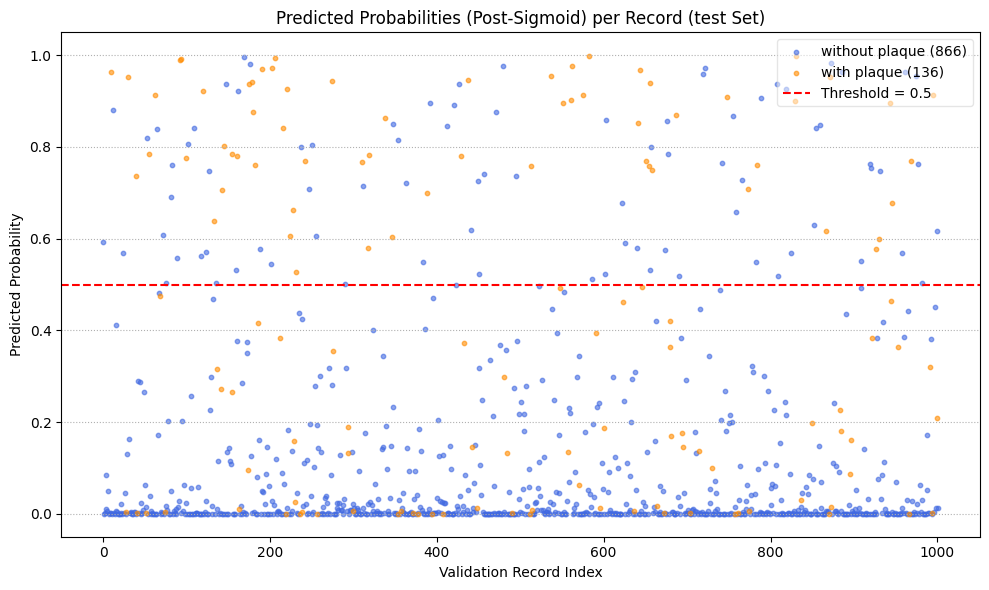

--- Probability Plotting Complete ---


In [82]:
# --- How to Use ---
# Assume 'mymodel' is your trained model returned from build_pretrained_model 
# (and potentially trained further by train_transfer_model)
# Assume 'val_dataset' is your validation tf.data.Dataset

plot_probabilities_per_record(model_for_initial_analysis, val_ds, dataset_name=dataset_name, config=my_config)


In [14]:
model_for_initial_analysis.summary()

Model: "resnet50_model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 preprocessing_layer (Lambd  (None, 256, 256, 3)          0         ['input_2[0][0]']             
 a)                                                                                               
                                                                                                  
 resnet50 (Functional)       (None, 8, 8, 2048)           2358771   ['preprocessing_layer[0][0]'] 
                                                          2                                       
                                                                                     

In [15]:
model = model_for_initial_analysis
for i, layer in enumerate(model.layers):
    if i < 4:
        layer.trainable = False
    else:
        print(f"layer {i} set to trainable")
        layer.trainable = True
print(f"Layer {15} and higher set to trainable in fine tuning step.")

model.trainable_weights

layer 4 set to trainable
layer 5 set to trainable
layer 6 set to trainable
layer 7 set to trainable
layer 8 set to trainable
layer 9 set to trainable
layer 10 set to trainable
layer 11 set to trainable
layer 12 set to trainable
layer 13 set to trainable
layer 14 set to trainable
layer 15 set to trainable
layer 16 set to trainable
layer 17 set to trainable
layer 18 set to trainable
Layer 15 and higher set to trainable in fine tuning step.


[<tf.Variable 'head_bn_1/gamma:0' shape=(4096,) dtype=float32, numpy=
 array([1.0052358 , 0.9993344 , 1.0009035 , ..., 0.99713594, 0.99839246,
        1.0234823 ], dtype=float32)>,
 <tf.Variable 'head_bn_1/beta:0' shape=(4096,) dtype=float32, numpy=
 array([-0.00835571,  0.00967099,  0.00973108, ..., -0.00143518,
        -0.00033886,  0.00122414], dtype=float32)>,
 <tf.Variable 'head_dense_1/kernel:0' shape=(4096, 512) dtype=float32, numpy=
 array([[-0.00062091, -0.00024184, -0.01279959, ...,  0.0036705 ,
          0.00065919, -0.00687697],
        [-0.00832922, -0.00039704,  0.00616814, ...,  0.0184704 ,
          0.00317591, -0.00230372],
        [-0.01567245, -0.0023259 ,  0.01667352, ...,  0.01560989,
          0.00256237, -0.01048157],
        ...,
        [-0.01005029,  0.01679043,  0.00123273, ..., -0.01082518,
          0.00080412, -0.00565313],
        [-0.00920752,  0.00525747, -0.00015869, ..., -0.00410826,
         -0.00052241, -0.00541761],
        [ 0.00011448,  0.0029918

In [ ]:



# --- Using the Custom Callback ---
# Modify your `train_transfer_model` function:

def train_transfer_model(mymodel, train_dataset, val_dataset, config: Config, save_models = True,
                         initial_weights_name="initial_weights",
                         fine_tuned_weights_name="fine_tuned_weights",
                         num = 1):

    # ... (previous setup code like log_dir creation) ...
    
    # Instantiate the custom callback
    # Decide how often you want the analysis (e.g., run_freq=3 means every 3 epochs)
    # Make sure log_dir is defined before this line
    output_analysis_callback = OutputAnalysisCallback(
        validation_data=val_dataset, 
        log_dir=os.path.join(log_dir, "output_analysis"), # Save plots in a subfolder
        run_freq=3 # Example: run every 3 epochs
    )

    # Add the callback to your lists
    initial_callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True), # Consider monitoring val_auc mode='max'
        ReduceLROnPlateau( monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1), # Consider monitoring val_auc mode='max'
        tensorboard_callback,
        output_analysis_callback # Add it here
    ]
    
    # ... (compile model for initial training) ...
    
    print("**************** Starting initial training **************** ")
    initial_history = mymodel.fit(
        # ...,
        callbacks=initial_callbacks,
        # ...
    )
    
    # ... (save initial weights / history logging) ...

    if config.NUM_FINE_TUNE_EPOCHS > 0:
        # ... (fine-tuning setup: unfreeze layers, etc.) ...
        
        # Define fine-tuning callbacks, INCLUDING the analysis callback again
        fine_tune_callbacks = [
            EarlyStopping(monitor='val_loss', patience=5, verbose=1, restore_best_weights=True), # Consider val_auc
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1), # Consider val_auc
            tensorboard_callback,
            output_analysis_callback # Add it here too
        ]
        
        # ... (compile model for fine-tuning) ...
        
        fine_tune_history = mymodel.fit(
            # ...,
            callbacks=fine_tune_callbacks,
            # ...
        )
        
        # ... (save fine-tuned weights / history logging) ...
    
    # ... (return statement) ...

Bad pipe message: %s [b'(Windows NT; Windows NT 10.0; fi-FI) WindowsPow']
Bad pipe message: %s [b"\xfexy\xad\xb8\xbe\xf6%\x95x0&\xce\x9f\xe2\xb8\xfeI \x86\xdan\xf4\xb5\xa9\xfc\xf5P\n8\x909\xae\xb2\x1dF\xecn\n\x0fPQxY\xccE0[&\xa6\x86\x00(\x13\x02\x13\x01\xc0,\xc0+\xc00\xc0/\xc0$\xc0#\xc0(\xc0'\xc0\n\xc0\t\xc0\x14\xc0\x13\x00\x9d\x00\x9c\x00=\x00<\x005\x00/\x01\x00\x00~\x00+\x00", b'\x03\x04\x03\x03\x03\x02\x03\x01']
Bad pipe message: %s [b'(Windows NT; Windows NT 10.0; fi-FI) WindowsPow']
Bad pipe message: %s [b"H\x14\xab\xbcL\xd1\xc5\x16\xbc8P\xad\x1a\xd4\xf4\x05\xfb| 2%t\xdb\xcd\xa1\xa8;\xae;:\xb2 \xe7\x84\xfa\x0f\xac;\x03\xd4\xb3qs\x96H\x98\x7f\xf8_\x8ew\x00(\x13\x02\x13\x01\xc0,\xc0+\xc00\xc0/\xc0$\xc0#\xc0(\xc0'\xc0\n\xc0\t\xc0\x14\xc0\x13\x00\x9d\x00\x9c\x00=\x00<\x005\x00/\x01\x00\x00~\x00+\x00\t\x08\x03\x04\x03\x03\x03\x02\x03\x01\x00\r\x00\x1a\x00\x18\x08\x04\x08\x05\x08\x06\x04\x01\x05\x01\x02\x01\x04\x03\x05\x03\x02", b'\x02\x06']
Bad pipe message: %s [b'']
Bad pipe message: 